# MSE 413 Assignment 1

## Simple linear Regression

In this machine learning model, data are feed into a simple linear regression. Root mean square error (RMSE) is investigated in this section with different splitting portion of the shuffle data.

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import joblib  # To save trained models
import matplotlib.pyplot as plt

In [17]:
# Load the training and testing datasets
df_train = pd.read_csv('training.csv')
df_test = pd.read_csv('testing.csv')

# Define targets and feature candidates
targets = ['TEY', 'CO', 'NOX']
features = ['AT','AP','AH','AFDP','GTEP','TIT','TAT','CDP']

# 1. Find the feature with the highest Pearson correlation for each target
correlations = df_train.corr()
best_features = {}

for target in targets:
    best_feature = correlations[target][features].abs().idxmax()  # Find feature with max abs correlation
    best_features[target] = best_feature

print("Best features for each target:", best_features)

Best features for each target: {'TEY': 'CDP', 'CO': 'TIT', 'NOX': 'AT'}


In [18]:
# 2. Build, train, and evaluate models
models = {}
results = {}

for target, feature in best_features.items():
    # Extract relevant feature and target
    X_train, y_train = df_train[[feature]], df_train[target]
    X_test, y_test = df_test[[feature]], df_test[target]

    # Train model
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Save trained model
    joblib.dump(model, f'model_{target}.pkl')

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Performance metrics
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    models[target] = model
    results[target] = {
        'feature': feature,
        'r2_train': r2_train,
        'r2_test': r2_test,
        'rmse_train': rmse_train,
        'rmse_test': rmse_test
    }

print("Model evaluation results:")
for result in results.items():
    print(result)

Model evaluation results:
('TEY', {'feature': 'CDP', 'r2_train': 0.9778139220147096, 'r2_test': 0.9771491118632684, 'rmse_train': 2.3266146266789898, 'rmse_test': 2.3598667016741994})
('CO', {'feature': 'TIT', 'r2_train': 0.5023517082609547, 'r2_test': 0.48567688201023285, 'rmse_train': 1.5837138942210818, 'rmse_test': 1.6723344051496747})
('NOX', {'feature': 'AT', 'r2_train': 0.3126654947873643, 'r2_test': 0.30681775692221813, 'rmse_train': 9.716063184280644, 'rmse_test': 9.58423768912581})


In [19]:
# 3. Train-test splits and model evaluation for AT → NOX

# Define train-test split percentages
splits = [0.5, 0.7, 0.8]
split_results = {}

# Feature: 'AT', Target: 'NOX'
X_full = df_train[['AT']]
y_full = df_train['NOX']

# Train and evaluate models for each split
for split in splits:
    X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=1-split, random_state=42)
    
    # Train model
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Compute RMSE
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    split_results[split] = {
        'rmse_train': rmse_train,
        'rmse_test': rmse_test
    }


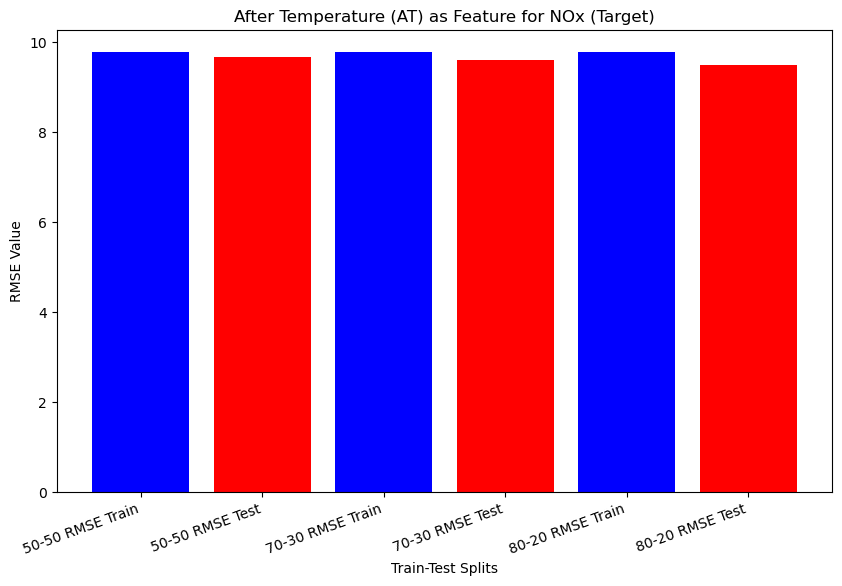

In [20]:
# Extract RMSE values for visualization
x_labels = [
    "50-50 RMSE Train", "50-50 RMSE Test",
    "70-30 RMSE Train", "70-30 RMSE Test",
    "80-20 RMSE Train", "80-20 RMSE Test"
]

y_values = [
    split_results[0.5]['rmse_train'], split_results[0.5]['rmse_test'],
    split_results[0.7]['rmse_train'], split_results[0.7]['rmse_test'],
    split_results[0.8]['rmse_train'], split_results[0.8]['rmse_test']
]

# Plot the bar chart
plt.figure(figsize=(10, 6))
plt.bar(x_labels, y_values, color=['blue', 'red', 'blue', 'red', 'blue', 'red'])

# Rotate x-axis labels for better readability
plt.xticks(rotation=20, ha='right')

# Title and labels
plt.title("After Temperature (AT) as Feature for NOx (Target)")
plt.ylabel("RMSE Value")
plt.xlabel("Train-Test Splits")

# Show the plot
plt.show()

Comparing RMSE values, discuss the performance of each model.
- The RMSE values are consistent through out all the splitting strategies of approximately 10. The testing has a lower error when the testing section as there are more data into the training and there is nothing more predict on the trend.